# Forward Sliding Window Decoding Tutorial

This notebook demonstrates the **forward sliding window decoder** for
rotated surface codes, implementing the algorithm from:

> Tan et al., "Scalable surface code decoders with parallelization in time",
> arXiv:2209.09219 (2022).

## Why sliding windows?

Full-circuit MWPM decoding builds a single matching graph over the entire
experiment -- all syndrome rounds at once.  This is optimal for accuracy but
has two problems at scale:

1. **Memory**: the matching graph grows linearly with the number of rounds.
2. **Latency**: decoding cannot begin until all syndrome data is collected.

Sliding window decoding fixes both by processing a fixed-size window of
`2d` rounds at a time (where `d` is the code distance), advancing by `d`
rounds per step.  Each window is decoded independently with MWPM, and
results are stitched together via **artificial defects**.

## Algorithm at a glance

Each window of `2d` rounds is split into:

- **Commit region** (first `d` rounds): corrections here are final.
- **Buffer region** (last `d` rounds): provides lookahead context but
  corrections here are discarded and re-decoded by the next window.

Key rules per window:

| Boundary | Treatment |
|---|---|
| **Past time boundary** | **Closed** -- error mechanisms touching earlier rounds are dropped (already committed) |
| **Future time boundary** | **Open** -- mechanisms reaching beyond the window become boundary edges |
| **Spatial boundaries** | **Open** -- handled by PyMatching's virtual boundary node |

Matched edges are classified as:

- **Core edges** (at least one endpoint in commit region): L0 contribution is committed.
  If the edge crosses into the buffer (C x B), the buffer endpoint becomes an
  **artificial defect** passed to the next window.
- **Buffer edges** (both endpoints in buffer): discarded entirely.

The **last window** commits all remaining rounds (no buffer), so every edge
is a core edge.

**Prerequisites:** `pip install stim pymatching numpy matplotlib`

In [1]:
import sys

sys.path.insert(0, "/Users/vishalsharma/Documents/gitrepos/Stim")

import math
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from glue.window_decoding.window_decomposition import (
    group_detectors_by_round,
    build_forward_window_dem,
)
from glue.window_decoding.experiment import (
    # run_full_decode,
    # run_sliding_window_decode,
    run_experiment,
    run_sweep,
    run_sweep_fixed_rounds,
    print_results_table,
)

## 1. Generate a Surface Code Circuit

We use Stim's built-in circuit generator for a **rotated surface code
memory-Z** experiment.  The circuit performs `total_rounds` syndrome
extraction rounds with depolarizing noise, then measures all data qubits.

Key parameters:
- `distance = 3` -- code distance (determines commit and buffer sizes)
- `total_rounds = 9` -- must be a multiple of `distance`
- `noise = 0.005` -- depolarization probability after each Clifford gate

In [2]:
code = "surface_code:rotated_memory_z"
distance = 5
total_rounds = 30
noise = 0.005

circuit = stim.Circuit.generated(
    code_task=code,
    distance=distance,
    rounds=total_rounds,
    after_clifford_depolarization=noise,
)

print(f"Code distance:  {distance}")
print(f"Total rounds:   {total_rounds}")
print(f"Noise:          {noise}")
print(f"Qubits:         {circuit.num_qubits}")
print(f"Detectors:      {circuit.num_detectors}")
print(f"Observables:    {circuit.num_observables}")

Code distance:  5
Total rounds:   30
Noise:          0.005
Qubits:         64
Detectors:      720
Observables:    1


## 2. Group Detectors by Syndrome Round

Each detector in a Stim-generated surface code circuit has coordinates
`(x, y, t)` where `t` is the syndrome round index.  The function
`group_detectors_by_round` maps detector indices to their round,
merging the thin final-measurement boundary layer into the last
syndrome round.

For a distance-3 code, each round has 8 detectors (4 X-type + 4 Z-type
stabilizers), except round 0 which has only 4 (initial boundary detectors).

In [3]:
by_round = group_detectors_by_round(circuit)

print(f"{'Round':>5}  {'# Dets':>6}  Detector indices")
print("-" * 55)
for t in sorted(by_round.keys()):
    dets = by_round[t]
    print(f"{t:>5}  {len(dets):>6}  {dets}")

Round  # Dets  Detector indices
-------------------------------------------------------
    0      12  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    1      24  [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
    2      24  [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
    3      24  [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
    4      24  [84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107]
    5      24  [108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131]
    6      24  [132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155]
    7      24  [156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,

## 3. Window Layout

With `d = 3`, each window covers `2d = 6` rounds (3 commit + 3 buffer)
and advances by `d = 3` rounds per step.  The number of windows is
`max(1, ceil((R - d) / d))` where `R` is the total number of rounds.

For `R = 9, d = 3`: `max(1, ceil(6/3)) = 2` windows.

```
Rounds:   0  1  2  3  4  5  6  7  8
Window 0: [commit ] [buffer ]
Window 1:          [  commit (last window, no buffer)  ]
```

Window 0 commits rounds 0-2, uses rounds 3-5 as buffer lookahead.
Window 1 is the last window, so it commits everything remaining (rounds 3-8).

In [4]:
n_com = distance
n_buf = distance
total_rounds_actual = max(by_round.keys()) + 1
num_windows = max(1, math.ceil((total_rounds_actual - n_buf) / n_com))

print(f"Commit size:  {n_com} rounds")
print(f"Buffer size:  {n_buf} rounds")
print(f"Window size:  {n_com + n_buf} rounds")
print(f"Total rounds: {total_rounds_actual}")
print(f"Num windows:  {num_windows}")
print()

for w in range(num_windows):
    commit_start = w * n_com
    is_last = w == num_windows - 1
    if is_last:
        commit_end = total_rounds_actual
        buf_end = total_rounds_actual
    else:
        commit_end = commit_start + n_com
        buf_end = commit_start + n_com + n_buf

    com_dets = [d for t in range(commit_start, commit_end) for d in by_round.get(t, [])]
    buf_dets = [d for t in range(commit_end, buf_end) for d in by_round.get(t, [])]

    print(f"Window {w}:")
    print(
        f"  Commit rounds [{commit_start}, {commit_end})  ->  {len(com_dets)} detectors"
    )
    if buf_end > commit_end:
        print(
            f"  Buffer rounds [{commit_end}, {buf_end})  ->  {len(buf_dets)} detectors"
        )
    else:
        print("  Buffer: none (last window)")
    print(f"  Total: {len(com_dets) + len(buf_dets)} detectors")

Commit size:  5 rounds
Buffer size:  5 rounds
Window size:  10 rounds
Total rounds: 30
Num windows:  5

Window 0:
  Commit rounds [0, 5)  ->  108 detectors
  Buffer rounds [5, 10)  ->  120 detectors
  Total: 228 detectors
Window 1:
  Commit rounds [5, 10)  ->  120 detectors
  Buffer rounds [10, 15)  ->  120 detectors
  Total: 240 detectors
Window 2:
  Commit rounds [10, 15)  ->  120 detectors
  Buffer rounds [15, 20)  ->  120 detectors
  Total: 240 detectors
Window 3:
  Commit rounds [15, 20)  ->  120 detectors
  Buffer rounds [20, 25)  ->  120 detectors
  Total: 240 detectors
Window 4:
  Commit rounds [20, 30)  ->  252 detectors
  Buffer: none (last window)
  Total: 252 detectors


## 4. Visualize Detector-to-Window Assignment

Each detector is colored by which window's commit region it belongs to.
Detectors in a window's buffer are shared with the next window's commit.

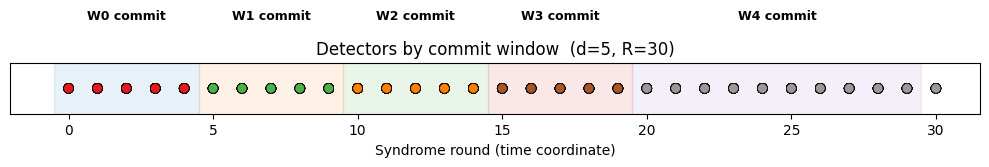

In [5]:
coords = circuit.get_detector_coordinates()

# Assign each detector to its commit window
det_window = {}
for t in sorted(by_round.keys()):
    w = t // n_com
    for d in by_round[t]:
        det_window[d] = min(w, num_windows - 1)

fig, ax = plt.subplots(figsize=(10, 4))
times = [coords[d][2] for d in range(circuit.num_detectors)]
colors = [det_window[d] for d in range(circuit.num_detectors)]
scatter = ax.scatter(
    times,
    [0] * len(times),
    c=colors,
    cmap="Set1",
    s=50,
    zorder=2,
    edgecolors="black",
    linewidths=0.5,
)

# Draw commit region boundaries
for w in range(num_windows):
    start = w * n_com - 0.5
    end = (w + 1) * n_com - 0.5 if w < num_windows - 1 else total_rounds_actual - 0.5
    ax.axvspan(start, end, alpha=0.1, color=f"C{w}")
    ax.text(
        (start + end) / 2,
        0.15,
        f"W{w} commit",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xlabel("Syndrome round (time coordinate)")
ax.set_yticks([])
ax.set_title(f"Detectors by commit window  (d={distance}, R={total_rounds})")
plt.tight_layout()
plt.show()

## 5. Building a Forward Window DEM

The core of the algorithm is `build_forward_window_dem`, which extracts a
sub-DEM for one window from the full circuit's DEM.  Let's inspect what
it produces for Window 0.

The **closed past boundary** means no mechanisms are dropped for Window 0
(nothing is before it).  The **open future boundary** means mechanisms
reaching beyond round 5 become single-detector boundary edges.

In [6]:
full_dem = circuit.detector_error_model(decompose_errors=True)
full_dem_errors = sum(1 for inst in full_dem.flattened() if inst.type == "error")

# Window 0: commit rounds [0,3), buffer rounds [3,6), past = empty
com_dets_w0 = [d for t in range(0, 3) for d in by_round.get(t, [])]
buf_dets_w0 = [d for t in range(3, 6) for d in by_round.get(t, [])]
window_dets_w0 = com_dets_w0 + buf_dets_w0
past_w0 = set()  # nothing before window 0

window_dem_w0 = build_forward_window_dem(full_dem, window_dets_w0, past_w0)
window_dem_errors_w0 = sum(
    1 for inst in window_dem_w0.flattened() if inst.type == "error"
)

# Window 1: commit rounds [3,9), past = rounds [0,3)
com_dets_w1 = [d for t in range(3, total_rounds_actual) for d in by_round.get(t, [])]
window_dets_w1 = com_dets_w1  # last window, no buffer
past_w1 = set(d for t in range(0, 3) for d in by_round.get(t, []))

window_dem_w1 = build_forward_window_dem(full_dem, window_dets_w1, past_w1)
window_dem_errors_w1 = sum(
    1 for inst in window_dem_w1.flattened() if inst.type == "error"
)

print(f"Full DEM:      {full_dem_errors} error mechanisms")
print(
    f"Window 0 DEM:  {window_dem_errors_w0} error mechanisms  "
    f"({len(window_dets_w0)} detectors: {len(com_dets_w0)} commit + {len(buf_dets_w0)} buffer)"
)
print(
    f"Window 1 DEM:  {window_dem_errors_w1} error mechanisms  "
    f"({len(window_dets_w1)} detectors: {len(com_dets_w1)} commit, last window)"
)
print("\nNote: Window 1 has fewer mechanisms because its closed past boundary")
print("drops cross-boundary mechanisms already committed by Window 0.")

Full DEM:      14427 error mechanisms
Window 0 DEM:  2674 error mechanisms  (132 detectors: 60 commit + 72 buffer)
Window 1 DEM:  13205 error mechanisms  (660 detectors: 660 commit, last window)

Note: Window 1 has fewer mechanisms because its closed past boundary
drops cross-boundary mechanisms already committed by Window 0.


## 6. Sanity Check: Zero Noise

With zero physical noise, both the full-circuit and sliding window decoders
must produce zero logical errors.  This validates that the window stitching
logic doesn't introduce spurious flips.

In [7]:
result_zero = run_experiment(distance=5, num_windows=5, noise=0.0, shots=1000)
assert result_zero.full_error_rate == 0.0, (
    "Full decode should have 0 errors at zero noise"
)
assert result_zero.sliding_window_error_rate == 0.0, (
    "Sliding window should have 0 errors at zero noise"
)
print("PASSED: both decoders give 0% error rate at zero noise.")

Experiment: d=5, rounds=30, window=5+5=10, p=0.0, shots=1000
  Full-circuit error rate:   0.000000
  Sliding window error rate: 0.000000
  Elapsed: 0.0s
PASSED: both decoders give 0% error rate at zero noise.


In [8]:
# import stim

# circuit = stim.Circuit.generated(
#     "surface_code:rotated_memory_z",
#     distance=5,
#     rounds=30,
#     after_clifford_depolarization=0.005,
# )
# det_coords_ckt = circuit.get_detector_coordinates()

# dem = circuit.detector_error_model(decompose_errors=True)
# det_coords_dem = dem.get_detector_coordinates()

# det_coords_dem == det_coords_ckt

# dem_compiler = dem.compile_sampler()

## 7. Single Experiment: Sliding Window vs Full Circuit

Now let's compare the two decoders on the same sampled detection events
with realistic noise.  The sliding window decoder should produce a logical
error rate very close to the full-circuit baseline (ratio near 1.0).

In [9]:
result = run_experiment(
    distance=3,
    num_windows=4,
    noise=0.001,
    shots=10_000,
)

ratio = (
    result.sliding_window_error_rate / result.full_error_rate
    if result.full_error_rate > 0
    else float("inf")
)
print(f"\nSliding/Full ratio: {ratio:.3f}")
print("(Expected: ~1.0 within statistical noise)")

Experiment: d=3, rounds=15, window=3+3=6, p=0.001, shots=10000
  Full-circuit error rate:   0.000700
  Sliding window error rate: 0.000700
  Elapsed: 0.1s

Sliding/Full ratio: 1.000
(Expected: ~1.0 within statistical noise)


## 8. Scaling with Number of Rounds

A key test: as we increase the number of rounds (more windows), the
sliding window error rate should stay close to the full-circuit rate.
If the algorithm has a stitching bug, the ratio would grow with the
number of windows.

In [10]:
d = 3
rounds_list = [3, 6, 9, 12, 15, 20]
shots = 100_000
p = 0.001

scaling_results = []
for r in rounds_list:
    res = run_experiment(distance=d, num_windows=r, noise=p, shots=shots)
    nw = max(1, math.ceil((r - d) / d))
    ratio = (
        res.sliding_window_error_rate / res.full_error_rate
        if res.full_error_rate > 0
        else float("inf")
    )
    scaling_results.append(
        (r, nw, res.full_error_rate, res.sliding_window_error_rate, ratio)
    )
    print()

print(
    f"{'Rounds':>6}  {'Windows':>7}  {'Full err':>10}  {'Window err':>10}  {'Ratio':>6}"
)
print("-" * 50)
for r, nw, fe, we, ratio in scaling_results:
    print(f"{r:>6}  {nw:>7}  {fe:>10.4f}  {we:>10.4f}  {ratio:>6.3f}")

Experiment: d=3, rounds=12, window=3+3=6, p=0.001, shots=100000
  Full-circuit error rate:   0.001000
  Sliding window error rate: 0.001010
  Elapsed: 0.6s

Experiment: d=3, rounds=21, window=3+3=6, p=0.001, shots=100000
  Full-circuit error rate:   0.002110
  Sliding window error rate: 0.002080
  Elapsed: 1.2s

Experiment: d=3, rounds=30, window=3+3=6, p=0.001, shots=100000
  Full-circuit error rate:   0.002790
  Sliding window error rate: 0.002810
  Elapsed: 1.9s

Experiment: d=3, rounds=39, window=3+3=6, p=0.001, shots=100000
  Full-circuit error rate:   0.003730
  Sliding window error rate: 0.003720
  Elapsed: 2.5s

Experiment: d=3, rounds=48, window=3+3=6, p=0.001, shots=100000
  Full-circuit error rate:   0.004360
  Sliding window error rate: 0.004380
  Elapsed: 3.2s

Experiment: d=3, rounds=63, window=3+3=6, p=0.001, shots=100000
  Full-circuit error rate:   0.006030
  Sliding window error rate: 0.006010
  Elapsed: 4.4s

Rounds  Windows    Full err  Window err   Ratio
----------

In [11]:
(res.sliding_window_error_rate) / (res.full_error_rate)

0.9966832504145937

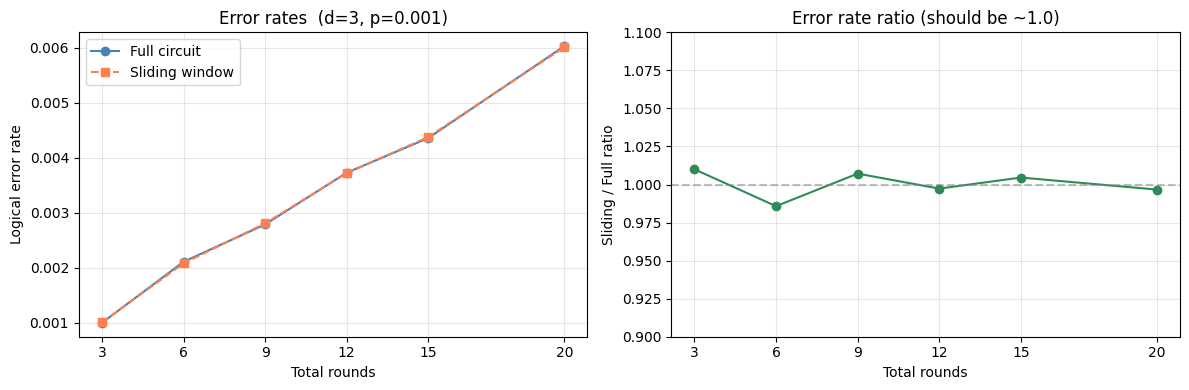

In [13]:
# Plot error rates vs rounds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

rounds_vals = [r[0] for r in scaling_results]
full_vals = [r[2] for r in scaling_results]
window_vals = [r[3] for r in scaling_results]
ratio_vals = [r[4] for r in scaling_results]

ax1.plot(rounds_vals, full_vals, "o-", label="Full circuit", color="steelblue")
ax1.plot(rounds_vals, window_vals, "s--", label="Sliding window", color="coral")
ax1.set_xlabel("Total rounds")
ax1.set_xticks(rounds_vals)
ax1.set_ylabel("Logical error rate")
# ax1.set_yscale("log")
ax1.set_title(f"Error rates  (d={d}, p={p})")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(rounds_vals, ratio_vals, "o-", color="seagreen")
ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Total rounds")
ax2.set_xticks(rounds_vals)
ax2.set_ylabel("Sliding / Full ratio")
ax2.set_title("Error rate ratio (should be ~1.0)")
ax2.set_ylim(0.9, 1.1)
ax2.grid(alpha=0.3)


plt.tight_layout()
plt.show()

## 9. Full Parameter Sweep

Sweep across distances `d = {3, 5}`, multiple round counts, and noise
levels to comprehensively verify the decoder.

In [14]:
results = run_sweep(
    distances=[3, 5, 7],
    num_windows_list=[5, 7, 9, 11, 13, 15],
    noise_levels=[0.0001, 0.0005, 0.001, 0.005],
    shots=50_000,
)

print("\n=== Results Summary ===")
print_results_table(results)

Experiment: d=3, rounds=18, window=3+3=6, p=0.0001, shots=50000
  Full-circuit error rate:   0.000020
  Sliding window error rate: 0.000020
  Elapsed: 0.4s

Experiment: d=3, rounds=18, window=3+3=6, p=0.0005, shots=50000
  Full-circuit error rate:   0.000460
  Sliding window error rate: 0.000460
  Elapsed: 0.5s

Experiment: d=3, rounds=18, window=3+3=6, p=0.001, shots=50000
  Full-circuit error rate:   0.001220
  Sliding window error rate: 0.001240
  Elapsed: 0.6s

Experiment: d=3, rounds=18, window=3+3=6, p=0.005, shots=50000
  Full-circuit error rate:   0.038940
  Sliding window error rate: 0.039020
  Elapsed: 1.1s

Experiment: d=3, rounds=24, window=3+3=6, p=0.0001, shots=50000
  Full-circuit error rate:   0.000020
  Sliding window error rate: 0.000020
  Elapsed: 0.6s

Experiment: d=3, rounds=24, window=3+3=6, p=0.0005, shots=50000
  Full-circuit error rate:   0.000660
  Sliding window error rate: 0.000640
  Elapsed: 0.7s

Experiment: d=3, rounds=24, window=3+3=6, p=0.001, shots=500

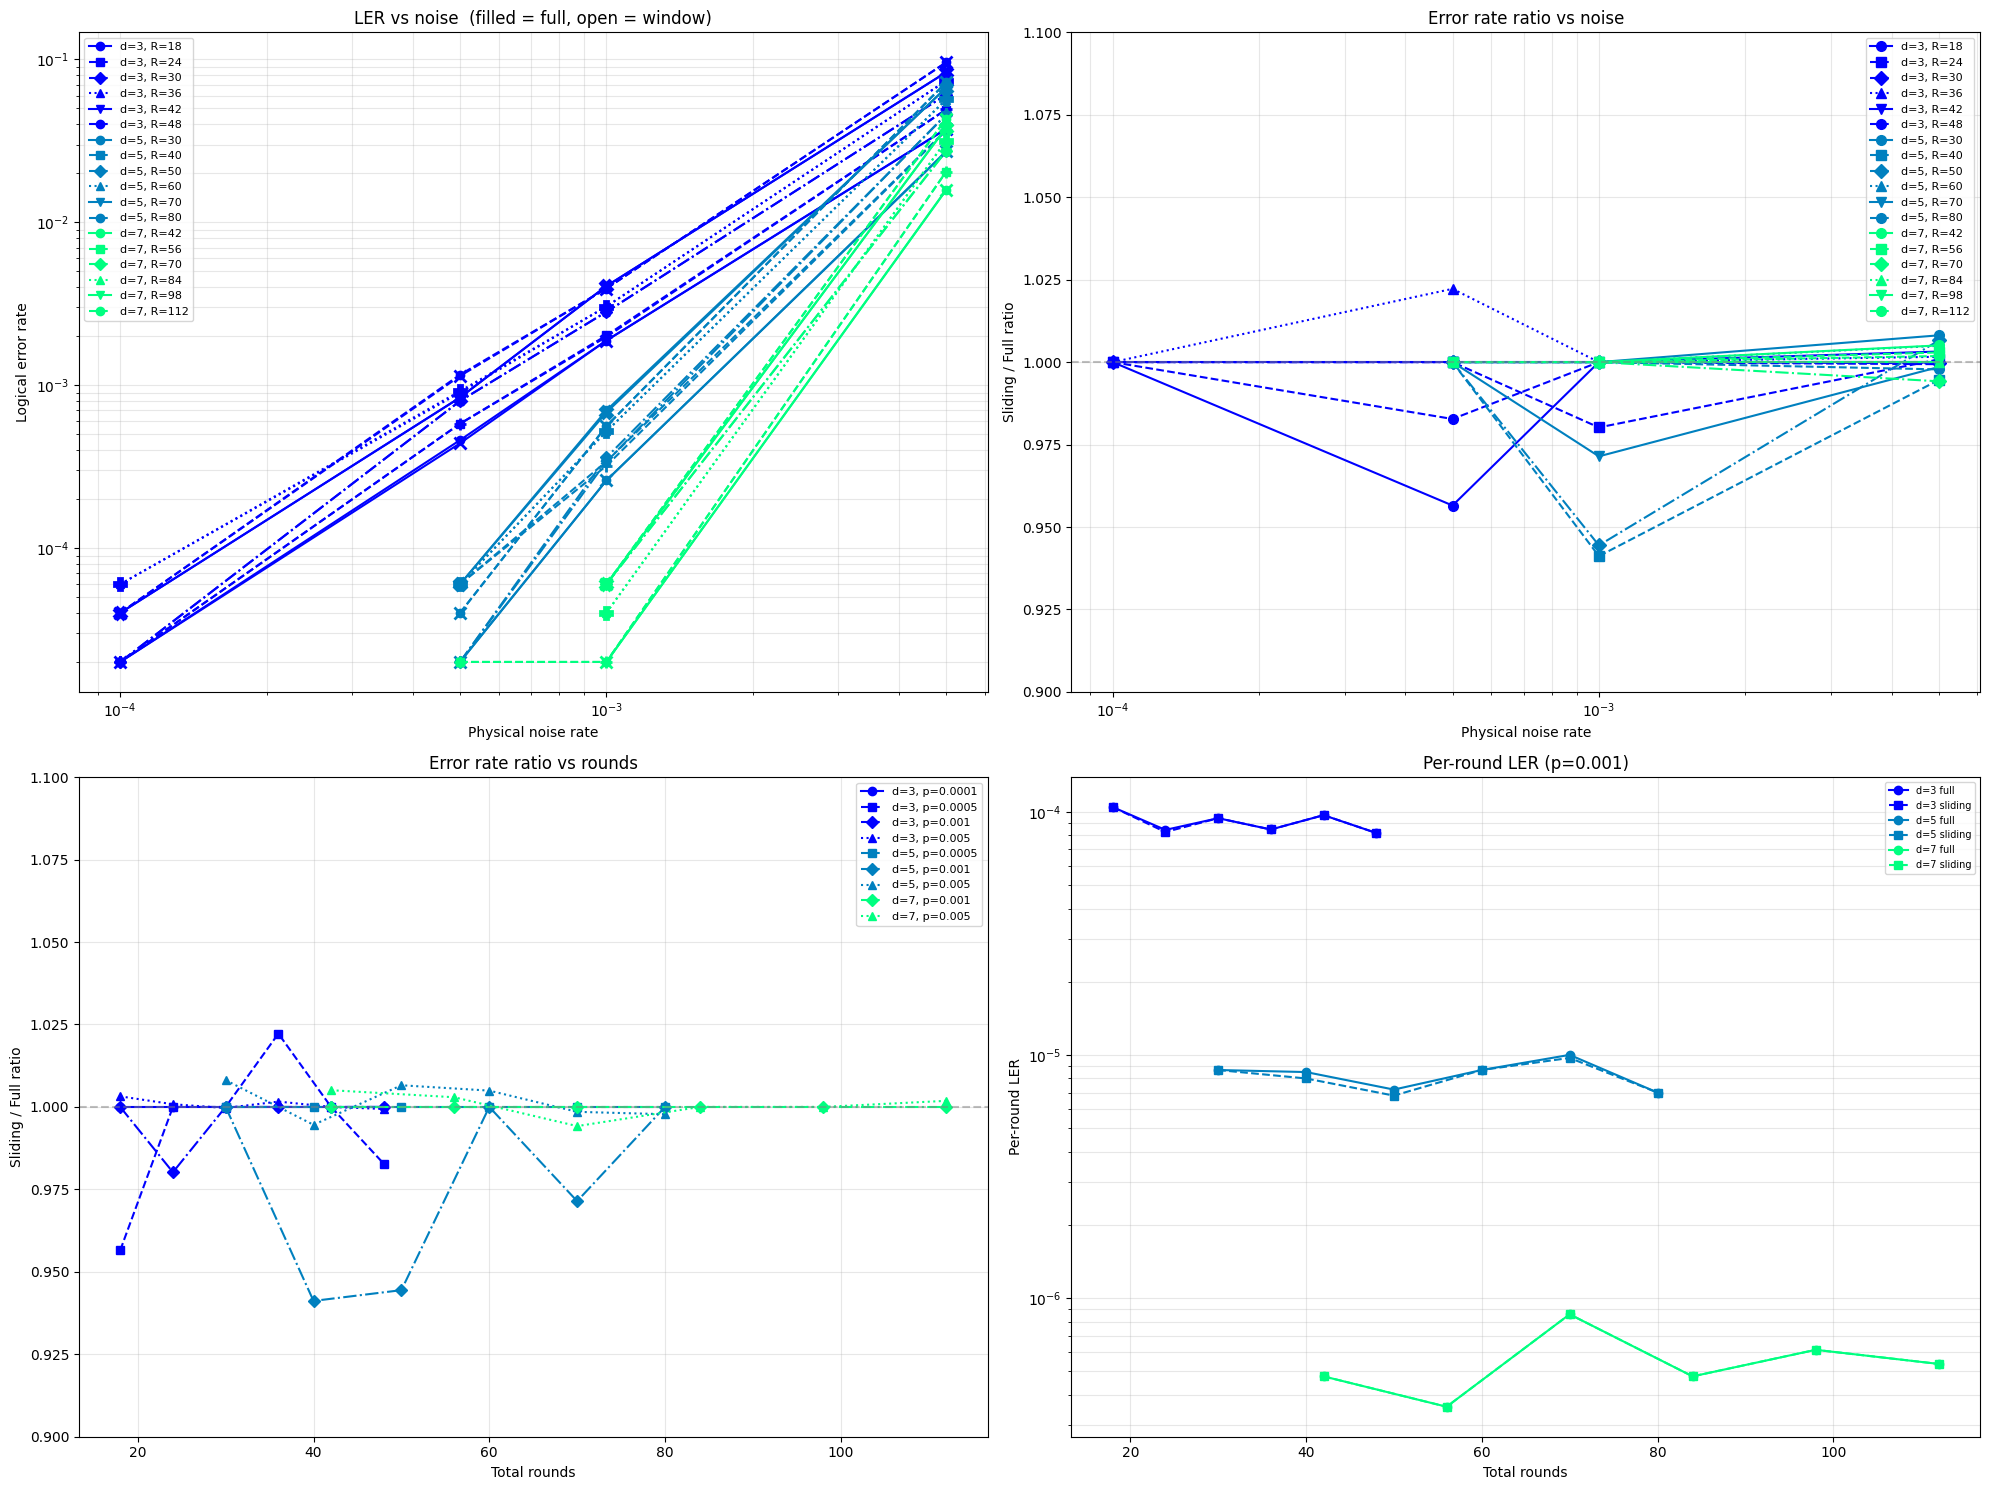

In [36]:
# --- Color palette setup ---
# Each distance gets a distinct color from a perceptually uniform colormap.
# Within a distance, line style varies by rounds/noise to keep things readable.
distances = sorted(set(r.distance for r in results))
d_colors = {
    d: cm.winter(i / max(len(distances) - 1, 1)) for i, d in enumerate(distances)
}
linestyles = ["-", "--", "-.", ":"]
markers_full = ["o", "s", "D", "^", "v"]
markers_window = ["x", "+", "*", "P", "X"]

fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# --- Top-left: LER vs noise (log-log), grouped by (d, rounds) ---
ax = axes[0, 0]
for d_val in distances:
    rounds_vals = sorted(set(r.total_rounds for r in results if r.distance == d_val))
    for j, r_val in enumerate(rounds_vals):
        subset = [
            r
            for r in results
            if r.distance == d_val and r.total_rounds == r_val and r.full_error_rate > 0
        ]
        if not subset:
            continue
        noise_vals = [r.noise for r in subset]
        full_vals = [r.full_error_rate for r in subset]
        window_vals = [r.sliding_window_error_rate for r in subset]
        ls = linestyles[j % len(linestyles)]
        mf = markers_full[j % len(markers_full)]
        mw = markers_window[j % len(markers_window)]
        ax.plot(
            noise_vals,
            full_vals,
            color=d_colors[d_val],
            marker=mf,
            linestyle=ls,
            label=f"d={d_val}, R={r_val}",
            markersize=6,
        )
        ax.plot(
            noise_vals,
            window_vals,
            color=d_colors[d_val],
            marker=mw,
            linestyle=ls,
            markersize=8,
            markeredgewidth=2,
            label="",
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Physical noise rate")
ax.set_ylabel("Logical error rate")
ax.set_title("LER vs noise  (filled = full, open = window)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

# --- Top-right: ratio vs noise, grouped by (d, rounds) ---
ax = axes[0, 1]
for d_val in distances:
    rounds_vals = sorted(set(r.total_rounds for r in results if r.distance == d_val))
    for j, r_val in enumerate(rounds_vals):
        subset = [
            r
            for r in results
            if r.distance == d_val and r.total_rounds == r_val and r.full_error_rate > 0
        ]
        if not subset:
            continue
        noise_vals = [r.noise for r in subset]
        ratios = [r.sliding_window_error_rate / r.full_error_rate for r in subset]
        ls = linestyles[j % len(linestyles)]
        mf = markers_full[j % len(markers_full)]
        ax.plot(
            noise_vals,
            ratios,
            color=d_colors[d_val],
            marker=mf,
            linestyle=ls,
            label=f"d={d_val}, R={r_val}",
            markersize=7,
        )

ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Physical noise rate")
ax.set_ylabel("Sliding / Full ratio")
ax.set_title("Error rate ratio vs noise")
ax.set_ylim(0.9, 1.1)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

# --- Bottom-left: ratio vs rounds, grouped by (d, noise) ---
ax = axes[1, 0]
noise_vals_all = sorted(set(r.noise for r in results))
for d_val in distances:
    for j, p_val in enumerate(noise_vals_all):
        subset = [
            r
            for r in results
            if r.distance == d_val and r.noise == p_val and r.full_error_rate > 0
        ]
        if len(subset) < 2:
            continue
        subset.sort(key=lambda r: r.total_rounds)
        rounds_list = [r.total_rounds for r in subset]
        ratios = [r.sliding_window_error_rate / r.full_error_rate for r in subset]
        ls = linestyles[j % len(linestyles)]
        mf = markers_full[j % len(markers_full)]
        ax.plot(
            rounds_list,
            ratios,
            color=d_colors[d_val],
            marker=mf,
            linestyle=ls,
            label=f"d={d_val}, p={p_val}",
            markersize=6,
        )

ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Total rounds")
ax.set_ylabel("Sliding / Full ratio")
ax.set_title("Error rate ratio vs rounds")
ax.set_ylim(0.9, 1.1)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Bottom-right: per-round LER, grouped by distance ---
ax = axes[1, 1]
for d_val in distances:
    subset = [
        r
        for r in results
        if r.distance == d_val and r.noise == 0.001 and r.full_error_rate > 0
    ]
    if not subset:
        continue
    subset.sort(key=lambda r: r.total_rounds)

    rounds = [r.total_rounds for r in subset]
    full_pr = [1 - (1 - r.full_error_rate) ** (1 / r.total_rounds) for r in subset]
    sw_pr = [
        1 - (1 - r.sliding_window_error_rate) ** (1 / r.total_rounds) for r in subset
    ]

    ax.plot(
        rounds,
        full_pr,
        color=d_colors[d_val],
        marker="o",
        linestyle="-",
        label=f"d={d_val} full",
        markersize=6,
    )
    ax.plot(
        rounds,
        sw_pr,
        color=d_colors[d_val],
        marker="s",
        linestyle="--",
        label=f"d={d_val} sliding",
        markersize=6,
    )

ax.set_xlabel("Total rounds")
ax.set_ylabel("Per-round LER")
ax.set_title("Per-round LER (p=0.001)")
ax.legend(fontsize=7)
ax.set_yscale("log")
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## 9b: Experiment to determine ideal commit/buffer size

In [3]:
# For fixed distance, num_windows, physical noise, plot LER vs commit+buffer window size. Expect LER to be stable until window size drops below distance, then degrade.
# Assume equal commit and buffer sizes, so window size = 2 * commit size.

d = 7
windows = 10
com_buf_sizes = [(i, i) for i in range(1, d + 2)]

results = run_sweep(
    distances=[d],
    num_windows_list=[windows],
    noise_levels=[0.005],
    com_buf_sizes_list=com_buf_sizes,
    shots=50_000,
)

print("\n=== Results Summary ===")
print_results_table(results)


Experiment: d=7, windows=10, rounds=11, window=1+1=2, p=0.005, shots=50000
  Full-circuit error rate:   0.003620
  Sliding window error rate: 0.021060
  Elapsed: 3.3s
Experiment: d=7, windows=10, rounds=22, window=2+2=4, p=0.005, shots=50000
  Full-circuit error rate:   0.008180


KeyboardInterrupt: 

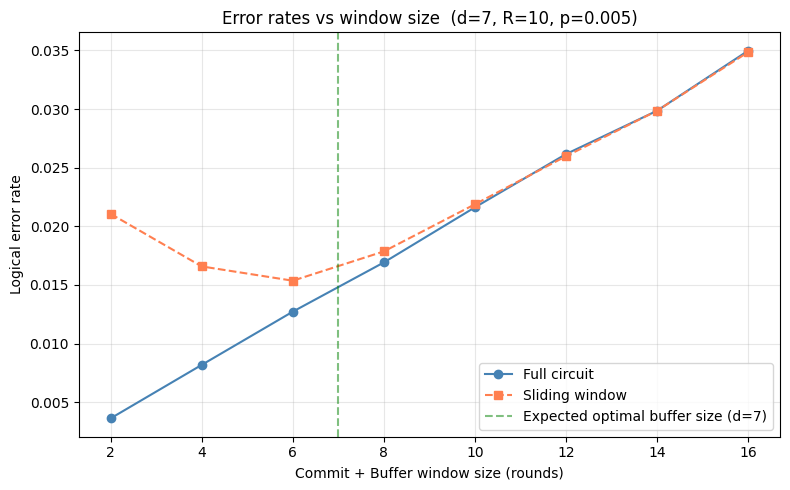

In [20]:
# plot the results above
fig, ax = plt.subplots(figsize=(8, 5))
sizes = [r.n_com + r.n_buf for r in results]
full_vals = [r.full_error_rate for r in results]
window_vals = [r.sliding_window_error_rate for r in results]
ax.plot(sizes, full_vals, "o-", label="Full circuit", color="steelblue")
ax.plot(sizes, window_vals, "s--", label="Sliding window", color="coral")
ax.axvline(
    d,
    color="green",
    linestyle="--",
    alpha=0.5,
    label=f"Expected optimal buffer size (d={d})",
)
ax.set_xlabel("Commit + Buffer window size (rounds)")
ax.set_ylabel("Logical error rate")
ax.set_title(f"Error rates vs window size  (d={d}, R={windows}, p=0.005)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
# For fixed distance, num_windows, physical noise, plot LER vs commit+buffer window size. Expect LER to be stable until window size drops below distance, then degrade.
# Assume equal commit and buffer sizes, so window size = 2 * commit size.

d = 5
com_buf_sizes = [(i, i) for i in range(1, d + 2)]

results = run_sweep_fixed_rounds(
    distances=[d],
    noise_levels=[0.002],
    com_buf_sizes_list=com_buf_sizes,
    shots=50_000,
)

print("\n=== Results Summary ===")
print_results_table(results)


Experiment: d=5, windows=239, rounds=240, window=1+1=2, p=0.002, shots=50000
  Full-circuit error rate:   0.015320
  Sliding window error rate: 0.087160
  Elapsed: 104.3s
Experiment: d=5, windows=119, rounds=240, window=2+2=4, p=0.002, shots=50000
  Full-circuit error rate:   0.015320
  Sliding window error rate: 0.021920
  Elapsed: 59.4s
Experiment: d=5, windows=79, rounds=240, window=3+3=6, p=0.002, shots=50000
  Full-circuit error rate:   0.015320
  Sliding window error rate: 0.015840
  Elapsed: 43.9s
Experiment: d=5, windows=59, rounds=240, window=4+4=8, p=0.002, shots=50000
  Full-circuit error rate:   0.015320
  Sliding window error rate: 0.015480
  Elapsed: 36.3s
Experiment: d=5, windows=47, rounds=240, window=5+5=10, p=0.002, shots=50000
  Full-circuit error rate:   0.015320
  Sliding window error rate: 0.015440
  Elapsed: 31.5s
Experiment: d=5, windows=39, rounds=240, window=6+6=12, p=0.002, shots=50000
  Full-circuit error rate:   0.015320
  Sliding window error rate: 0.01528

In [3]:
results

[ExperimentResult(distance=5, num_windows=np.int64(239), total_rounds=np.int64(240), noise=0.002, shots=50000, n_com=1, n_buf=1, full_error_rate=0.01532, sliding_window_error_rate=0.08716, elapsed_seconds=104.29997897148132),
 ExperimentResult(distance=5, num_windows=np.int64(119), total_rounds=np.int64(240), noise=0.002, shots=50000, n_com=2, n_buf=2, full_error_rate=0.01532, sliding_window_error_rate=0.02192, elapsed_seconds=59.36235785484314),
 ExperimentResult(distance=5, num_windows=np.int64(79), total_rounds=np.int64(240), noise=0.002, shots=50000, n_com=3, n_buf=3, full_error_rate=0.01532, sliding_window_error_rate=0.01584, elapsed_seconds=43.91189002990723),
 ExperimentResult(distance=5, num_windows=np.int64(59), total_rounds=np.int64(240), noise=0.002, shots=50000, n_com=4, n_buf=4, full_error_rate=0.01532, sliding_window_error_rate=0.01548, elapsed_seconds=36.33995532989502),
 ExperimentResult(distance=5, num_windows=np.int64(47), total_rounds=np.int64(240), noise=0.002, shot

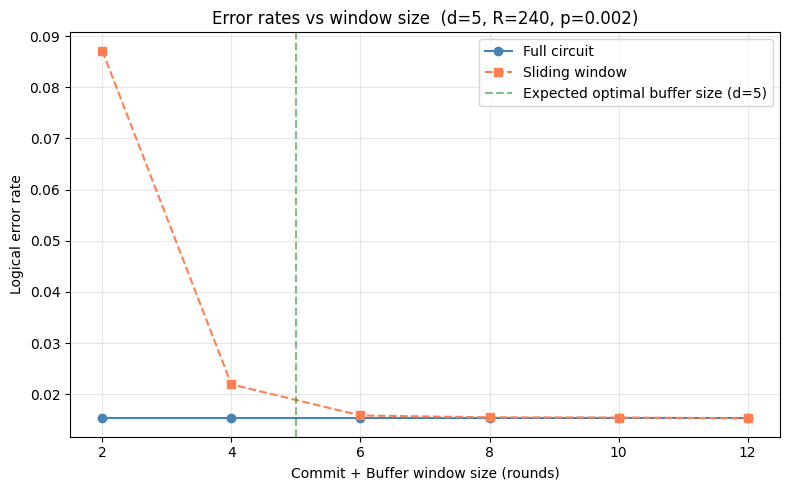

In [6]:
# plot the results above
fig, ax = plt.subplots(figsize=(8, 5))
sizes = [r.n_com + r.n_buf for r in results]
full_vals = [r.full_error_rate for r in results]
window_vals = [r.sliding_window_error_rate for r in results]
ax.plot(sizes, full_vals, "o-", label="Full circuit", color="steelblue")
ax.plot(sizes, window_vals, "s--", label="Sliding window", color="coral")
ax.axvline(
    d,
    color="green",
    linestyle="--",
    alpha=0.5,
    label=f"Expected optimal buffer size (d={d})",
)
ax.set_xlabel("Commit + Buffer window size (rounds)")
ax.set_ylabel("Logical error rate")
ax.set_title(f"Error rates vs window size  (d={d}, R={results[0].total_rounds}, p=0.002)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Step-by-Step: Manual Window Decode

For deeper understanding, let's manually walk through the sliding window
decode on a small example, showing the syndrome, matched edges, edge
classification, and artificial defect passing.

In [ ]:
from glue.window_decoding.experiment import _build_edge_obs_lookup

# Generate a small circuit and sample one shot
d = 3
R = 9
p = 0.01  # slightly higher noise so we see some defects
small_circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=d,
    rounds=R,
    after_clifford_depolarization=p,
)

# Sample until we get a shot with some defects
np.random.seed(42)
sampler = small_circuit.compile_detector_sampler()
det_events, obs_actual = sampler.sample(shots=100, separate_observables=True)

# Pick a shot with a reasonable number of defects
defect_counts = det_events.sum(axis=1)
shot_idx = np.argmax((defect_counts >= 3) & (defect_counts <= 10))
shot_det = det_events[shot_idx]
shot_obs = obs_actual[shot_idx]

triggered = np.where(shot_det)[0]
print(f"Shot {shot_idx}: {len(triggered)} triggered detectors")
print(f"  Detector indices: {list(triggered)}")
print(f"  Actual observable: {shot_obs[0]}")

# Map triggered detectors to rounds
by_round_small = group_detectors_by_round(small_circuit)
for det_idx in triggered:
    for t, dets in by_round_small.items():
        if det_idx in dets:
            print(f"  D{det_idx} -> round {t}")
            break

Shot 0: 6 triggered detectors
  Detector indices: [np.int64(2), np.int64(3), np.int64(6), np.int64(20), np.int64(21), np.int64(28)]
  Actual observable: True
  D2 -> round 0
  D3 -> round 0
  D6 -> round 1
  D20 -> round 3
  D21 -> round 3
  D28 -> round 4


In [ ]:
# Walk through the windows manually for this shot
full_dem_small = small_circuit.detector_error_model(decompose_errors=True)
total_rounds_small = max(by_round_small.keys()) + 1
num_windows_small = max(1, math.ceil((total_rounds_small - d) / d))

artificial_defects_global = []
final_obs = False

for w in range(num_windows_small):
    commit_start = w * d
    is_last = w == num_windows_small - 1
    commit_end = total_rounds_small if is_last else commit_start + d
    buf_end = (
        total_rounds_small if is_last else min(commit_start + 2 * d, total_rounds_small)
    )

    com_dets = [
        det
        for t in range(commit_start, commit_end)
        for det in by_round_small.get(t, [])
    ]
    buf_dets = [
        det for t in range(commit_end, buf_end) for det in by_round_small.get(t, [])
    ]
    window_dets = com_dets + buf_dets
    n_com_dets = len(com_dets)

    past = set(det for t in range(0, commit_start) for det in by_round_small.get(t, []))
    wdem = build_forward_window_dem(full_dem_small, window_dets, past)

    global_to_local = {g: i for i, g in enumerate(window_dets)}
    syndrome = shot_det[window_dets].copy().astype(bool)

    # Inject artificial defects
    for gidx in artificial_defects_global:
        local = global_to_local.get(gidx)
        if local is not None:
            syndrome[local] ^= True

    matcher = pymatching.Matching.from_detector_error_model(wdem)
    edge_obs = _build_edge_obs_lookup(matcher)

    print(f"--- Window {w} ---")
    print(
        f"  Commit rounds [{commit_start}, {commit_end}), "
        f"Buffer rounds [{commit_end}, {buf_end})"
        if not is_last
        else f"  Commit rounds [{commit_start}, {commit_end}) [last window, no buffer]"
    )
    print(f"  Inherited artificial defects: {artificial_defects_global}")

    triggered_local = np.where(syndrome)[0]
    print(f"  Active syndrome (local): {list(triggered_local)}")

    if not np.any(syndrome):
        print(f"  No defects -> skip")
        artificial_defects_global = []
        continue

    edges = matcher.decode_to_edges_array(syndrome)
    obs_flip = False
    new_artificial = []

    for edge in edges:
        u, v = int(edge[0]), int(edge[1])
        u_in_com = 0 <= u < n_com_dets
        v_in_com = 0 <= v < n_com_dets
        is_core = u_in_com or v_in_com
        has_l0 = edge_obs.get((u, v), False)

        # Classify
        u_label = (
            f"C(local={u})" if u_in_com else (f"B(local={u})" if 0 <= u else "bnd")
        )
        v_label = (
            f"C(local={v})" if v_in_com else (f"B(local={v})" if 0 <= v else "bnd")
        )
        kind = "CORE" if is_core else "BUFFER"

        print(f"  Edge ({u_label}, {v_label}): {kind}, L0={has_l0}", end="")

        if is_core:
            if has_l0:
                obs_flip = not obs_flip
                print(" -> COMMIT L0", end="")
            u_in_buf = n_com_dets <= u < len(window_dets)
            v_in_buf = n_com_dets <= v < len(window_dets)
            if u_in_buf:
                new_artificial.append(window_dets[u])
                print(f" -> artificial D{window_dets[u]}", end="")
            if v_in_buf:
                new_artificial.append(window_dets[v])
                print(f" -> artificial D{window_dets[v]}", end="")
        else:
            print(" -> DISCARD", end="")
        print()

    if obs_flip:
        final_obs = not final_obs
    artificial_defects_global = new_artificial
    print(f"  Window obs flip: {obs_flip}, running total: {final_obs}")
    print(f"  Artificial defects passed forward: {new_artificial}")
    print()

print(f"Final prediction: {final_obs}")
print(f"Actual observable: {bool(shot_obs[0])}")
print(f"Correct: {final_obs == bool(shot_obs[0])}")

--- Window 0 ---
  Commit rounds [0, 3), Buffer rounds [3, 6)
  Inherited artificial defects: []
  Active syndrome (local): [np.int64(2), np.int64(3), np.int64(6), np.int64(20), np.int64(21), np.int64(28)]
  Edge (C(local=2), C(local=3)): CORE, L0=False
  Edge (C(local=6), bnd): CORE, L0=False
  Edge (B(local=20), B(local=28)): BUFFER, L0=False -> DISCARD
  Edge (B(local=21), bnd): BUFFER, L0=True -> DISCARD
  Window obs flip: False, running total: False
  Artificial defects passed forward: []

--- Window 1 ---
  Commit rounds [3, 9) [last window, no buffer]
  Inherited artificial defects: []
  Active syndrome (local): [np.int64(0), np.int64(1), np.int64(8)]
  Edge (C(local=0), C(local=8)): CORE, L0=False
  Edge (C(local=1), bnd): CORE, L0=True -> COMMIT L0
  Window obs flip: True, running total: True
  Artificial defects passed forward: []

Final prediction: True
Actual observable: True
Correct: True


## Summary

This tutorial demonstrated the forward sliding window decoder:

1. **Circuit generation**: Stim generates a rotated surface code circuit
   with detectors labeled by `(x, y, t)` coordinates.

2. **Detector grouping**: `group_detectors_by_round` maps detectors to
   their syndrome round, handling the final measurement boundary layer.

3. **Window DEM construction**: `build_forward_window_dem` extracts a
   sub-DEM per window with a closed past boundary (prevents
   double-counting) and open future boundary (boundary edges for
   lookahead context).

4. **Decoding and stitching**: Each window is decoded with MWPM via
   PyMatching.  Core edges (touching the commit region) have their L0
   committed.  C x B edges produce artificial defects for the next window.
   Buffer-only edges are discarded.

5. **Verification**: The sliding window error rate matches the full-circuit
   baseline (ratio ~1.0) across distances, round counts, and noise levels,
   confirming correct implementation of the Tan et al. (2022) algorithm.